In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

In [4]:
data=pd.read_csv("ic272_lab4_rent.csv")
data.head()

,area,rooms,age,dist_km,floors,rent
0,6.95,1.0,2.07,3.37,3.0,49.43
1,6.60,1.0,4.16,2.75,3.0,49.77
2,7.94,3.0,1.55,1.50,3.0,67.01
3,8.11,1.0,4.63,8.55,3.0,47.21
4,6.08,2.0,3.04,2.99,1.0,45.25


In [5]:
data.describe()

,area,rooms,age,dist_km,floors,rent
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,7.266100,3.046667,3.959333,4.987433,1.986667,54.404133
std,1.278202,1.425223,2.199084,2.319815,0.817752,10.645547
min,5.050000,1.000000,0.000000,1.020000,1.000000,29.550000
25%,6.197500,2.000000,2.227500,2.887500,1.000000,47.345000
50%,7.355000,3.000000,3.915000,4.960000,2.000000,54.150000
75%,8.237500,4.000000,5.750000,7.065000,3.000000,61.820000
max,9.500000,5.000000,7.950000,8.910000,3.000000,85.940000


In [10]:
def train_test_split_scratch(X,y,test_frac,seed):
    np.random.default_rng(seed)
    n=int(len(X)*test_frac)
    idx=np.random.permutation(np.arange(len(X)))
    X_test=X.iloc[idx[:n]]
    y_test=y.iloc[idx[:n]]
    X_train=X.iloc[idx[n:]]
    y_train=y.iloc[idx[n:]]
    return X_train, X_test, y_train,y_test
a,b,c,d=train_test_split_scratch(data[['area','rooms','age','dist_km','floors']],data['rent'],0.2,42)

In [14]:
def fit_simple_lr(x,y):
    x_mean=np.mean(x)
    y_mean=np.mean(y)
    w=np.sum((x-x_mean)*(y-y_mean))/np.sum((x-x_mean)**2)
    b=y_mean-w*x_mean
    return w,b
w,b=fit_simple_lr(data['area'],data['rent'])
print(f"w:{w:.3f}\nb:{b:.3f}")

w:5.743
b:12.674


Text(0, 0.5, 'rent')

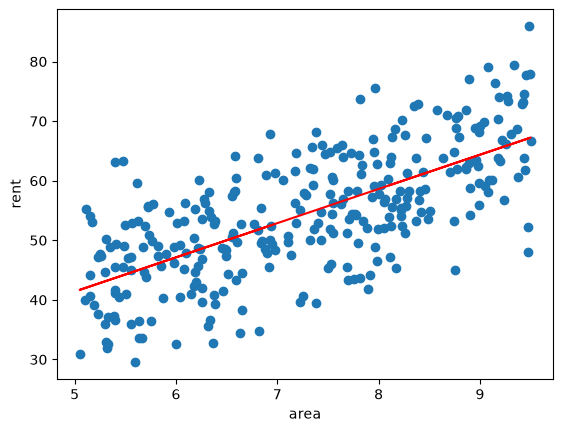

In [16]:
plt.scatter(data['area'],data['rent'])
plt.plot(data['area'],w*data['area']+b,color='red',label='fit')
plt.xlabel('area')
plt.ylabel('rent')

In [21]:
def design_matrix(X):
    return np.column_stack((np.ones(len(X)),X))
x=design_matrix(data['area'])
print(x[:5])

[[1.   6.95]
 [1.   6.6 ]
 [1.   7.94]
 [1.   8.11]
 [1.   6.08]]


In [29]:
def fit_normal_equation(X,y):
    A=design_matrix(X)
    Aty=A.T@y
    AtA=A.T@A
    theta_hat=np.linalg.solve(AtA,Aty)#using np.linalg.solve as this is much computationally efficient due to the form ATA which means it can be solveed by cholesky decomposition and hence computationally mmuch faster than inverse
    return theta_hat

In [30]:
X_train, X_test, y_train,y_test=train_test_split_scratch(data[['area','rooms','age','dist_km','floors']],data['rent'],0.2,42)

In [60]:
df2 = pd.DataFrame(
    {
        "A": 1.0,
        "B": pd.Timestamp("20130102"),
        "C": pd.Series(1, index=list(range(4)), dtype="float32"),
        "D": np.array([3] * 4, dtype="int32"),
        "E": pd.Categorical(["test", "train", "test", "train"]),
        "F": "foo",
    }
)
df2.head()

,A,B,C,D,E,F
0,1.0,2013-01-02,1.0,3,test,foo
1,1.0,2013-01-02,1.0,3,train,foo
2,1.0,2013-01-02,1.0,3,test,foo
3,1.0,2013-01-02,1.0,3,train,foo


In [62]:
theta_hat_2=fit_normal_equation(X_train,y_train)
print(theta_hat_2)
# parameters_2=pd.DataFrame(
#     {"Intercept": theta_hat_2[0],
#      "Area": theta_hat_2[1],
#      "Rooms":theta_hat_2[2],
#      "Age":theta_hat_2[3],
#      "dist_km": theta_hat_2[4],
#      "floors": theta_hat_2[5],
# }
# )
print(f"Intercept: {theta_hat_2[0]}")
print(f"area: {theta_hat_2[1]}")
print(f"rooms: {theta_hat_2[2]}")
print(f"age: {theta_hat_2[3]}")
print(f"dist_km: {theta_hat_2[4]}")
print(f"floors: {theta_hat_2[5]}")

[12.42401918  6.05655813  3.11434004 -1.39396016 -1.92521674  1.84692193]
Intercept: 12.424019178840318
area: 6.056558129074906
rooms: 3.114340037960183
age: -1.3939601611416097
dist_km: -1.9252167412338888
floors: 1.8469219290622194


In [50]:
def fit_gradient_descent(X, y, lr, n_iters):
    A = design_matrix(X)
    n = A.shape[0]
    theta = np.zeros(A.shape[1])
    history = []
    t1=time.time()
    for _ in range(n_iters):

        error = A @ theta - y
        loss = (1/n) * np.sum(error**2)
        history.append(loss)
        gradient = (2/n) * A.T @ error
        theta = theta - lr * gradient
    t2=time.time()
    print(f"[INFO] Time taken for training: {t2-t1} seconds")
    return theta, history

In [77]:
theta_hat_3,history=fit_gradient_descent(X_train,y_train,0.005,20000)


[INFO] Time taken for training: 3.72114634513855 seconds


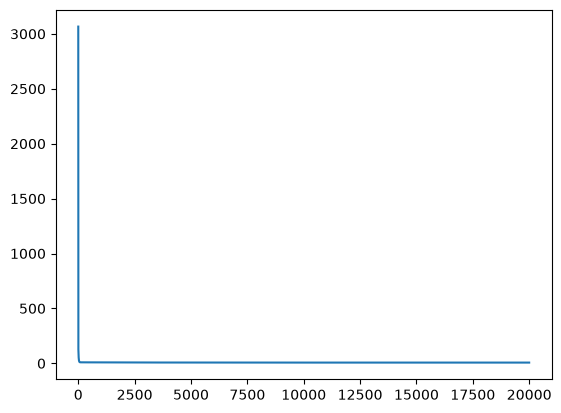

In [101]:
plt.plot(history)

In [71]:
print("MATRIX_METHOD,GRADIENT_DESCENT")
diff=[]
for i in range(len(theta_hat_2)):
    
    print(f"{float(theta_hat_2[i]),float(theta_hat_3[i]),},diff:{theta_hat_3[i]-theta_hat_2[i]}")
    diff.append(abs(theta_hat_3[i]-theta_hat_2[i]))
print(np.max(diff))

MATRIX_METHOD,GRADIENT_DESCENT
(12.424019178840318, 12.1196729649553),diff:-0.3043462138850188
(6.056558129074906, 6.08131782849337),diff:0.02475969941846401
(3.114340037960183, 3.123592865496711),diff:0.00925282753652823
(-1.3939601611416097, -1.3882924377664903),diff:0.005667723375119449
(-1.9252167412338888, -1.9192598781520276),diff:0.005956863081861163
(1.8469219290622194, 1.8669566571317369),diff:0.02003472806951745
0.3043462138850188


In [78]:
lr=[0.001,0.005,0.01]
loss=[[],[],[]]
for i in range(len(lr)):
    t,loss[i]=fit_gradient_descent(X_train,y_train,lr[i],20000)


[INFO] Time taken for training: 3.6581809520721436 seconds
[INFO] Time taken for training: 3.627603769302368 seconds


/tmp/ipykernel_85447/3832568305.py:13: RuntimeWarning: invalid value encountered in subtract
  theta = theta - lr * gradient


[INFO] Time taken for training: 3.7318015098571777 seconds


In [79]:
x=[[],[],[]]
x[0]=[1,2,3]
print(x)

[[1, 2, 3], [], []]


/tmp/ipykernel_85447/3652866701.py:3: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(loss[2]))


Text(0, 0.5, 'log(loss)')

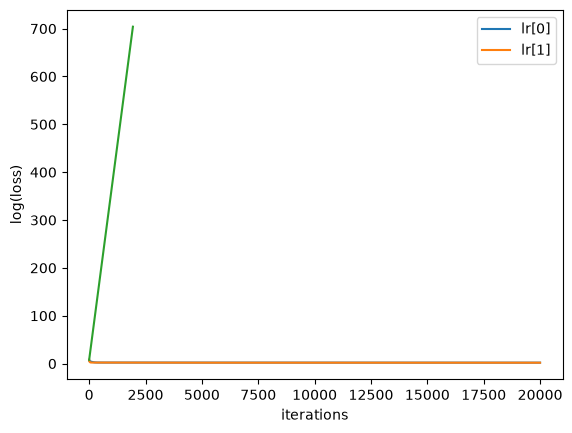

In [102]:
plt.plot(np.log(loss[0]))
plt.plot(np.log(loss[1]))
plt.plot(np.log(loss[2]))
plt.xlabel("iterations")
plt.legend(["lr[0]","lr[1]"])
plt.ylabel("log(loss)")

Test RMSE: 2.4386
Test R2:   0.9377
Train R2:  0.9428


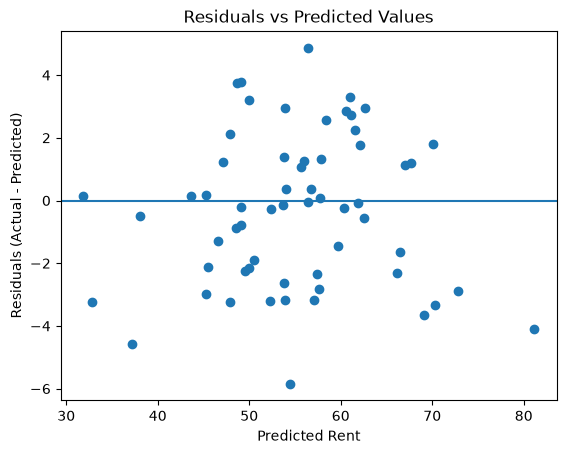

In [100]:
def rmse(y_true, y_pred):
    n = len(y_true)
    return np.sqrt((1/n) * np.sum((y_true - y_pred)**2))

def r2_score_scratch(y_true, y_pred):
    y_mean = np.mean(y_true)
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_mean)**2)
    return 1 - (ss_res / ss_tot)
A_test = design_matrix(X_test)
y_pred_test = A_test @ theta_hat_3
A_train = design_matrix(X_train)
y_pred_train = A_train @ theta_hat_3
print(f"Test RMSE: {rmse(y_test, y_pred_test):.4f}")
print(f"Test R2:   {r2_score_scratch(y_test, y_pred_test):.4f}")
print(f"Train R2:  {r2_score_scratch(y_train, y_pred_train):.4f}")
residuals = y_test - y_pred_test
plt.scatter(y_pred_test, residuals)
plt.axhline(0)
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Rent')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()